<a href="https://colab.research.google.com/github/affreen/affreen_ai_ml/blob/create_model/01_my_first_neural_network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
import torch
import torch.nn as nn
import torch.nn.functional as F


In [29]:
# Create a Model Class that inherits nn.Module

class Model(nn.Module):
  # Input Layer (4 features of the flower) -->
  # Hidden Layer 1 -->
  # Hidden Layer 2 -->
  # output (tell us the class of the flower)
  def __init__(self, in_features=4, h1=5, h2=7, out_features=3):
     super().__init__()
     self.fc1 = nn.Linear(in_features, h1)
     self.fc2 = nn.Linear(h1, h2)
     self.out = nn.Linear(h2, out_features)

  def forward(self, x):
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.out(x)
    return x


In [10]:
torch.manual_seed(14)

model = Model()

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [16]:
url = 'https://gist.githubusercontent.com/netj/8836201/raw/6f9306ad21398ea43cba4f7d537619d0e07d5ae3/iris.csv'
my_df = pd.read_csv(url)
my_df.head()


,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [18]:
my_df['variety'] = my_df['variety'].replace('Setosa', 0.0)
my_df['variety'] = my_df['variety'].replace('Versicolor', 1.0)
my_df['variety'] = my_df['variety'].replace('Virginica', 2.0)
my_df


,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


In [24]:
# Train test and split ! Set X, y

X = my_df.drop('variety', axis=1)
y = my_df['variety']


In [25]:
# Convert X and y to numpy arrays
X = X.values
y = y.values

In [26]:
from sklearn.model_selection import train_test_split

# Train test and split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=14)

# Convert X features to float tensors
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

# Convert y features to tensors long
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)


In [32]:
# Set the criterion of model to measure the error, how far off the predictions are from the data
criterion = nn.CrossEntropyLoss()

# Choose Optimizer, lr = learning rate
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)




In [76]:
epochs = 100
losses = []

for i in range(epochs):
  y_pred = model.forward(X_train) # Go forward and get a prediction

  loss = criterion(y_pred, y_train) # predicted values vs train values

  losses.append(loss.detach().numpy()) # Keep track of our loses

  if i % 10 == 0:
    print(f'Epoch: {i} and loss: {loss}')

  # Do some back propagation
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

Epoch: 0 and loss: 0.04783889278769493
Epoch: 10 and loss: 0.04960576072335243
Epoch: 20 and loss: 0.049299206584692
Epoch: 30 and loss: 0.04835571348667145
Epoch: 40 and loss: 0.04801743105053902
Epoch: 50 and loss: 0.04789892956614494
Epoch: 60 and loss: 0.04785691946744919
Epoch: 70 and loss: 0.04784106835722923
Epoch: 80 and loss: 0.04783469811081886
Epoch: 90 and loss: 0.04783269017934799


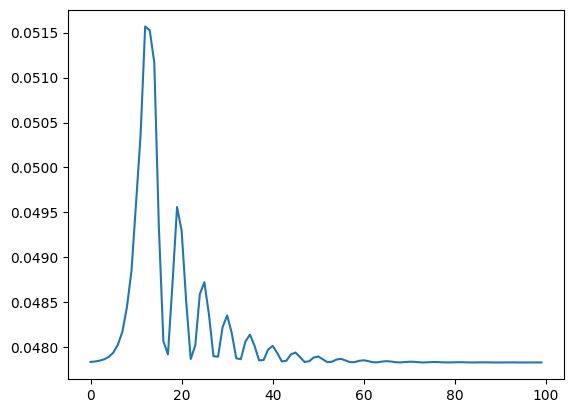

In [77]:
plt.plot(range(epochs), losses)